# Análise Exploratória de Dados — Santa Catarina (SC)

## 1. Apresentação da Base e Objetivos
Este estudo analisa os dados de votação por seção eleitoral no estado de Santa Catarina (SC) nas eleições de 2022 (`detalhe_votacao_secao_2022_SC.csv`). O objetivo é identificar padrões de engajamento eleitoral, analisar o comportamento do eleitor catarinense e verificar a qualidade dos dados.

### Origem dos Dados e Recorte Temporal
- **Fonte:** Tribunal Superior Eleitoral (TSE) — Portal de Dados Abertos.
- **Arquivo:** `detalhe_votacao_secao_2022_SC.csv`
- **Recorte Temporal:** Eleições Gerais de 2022 (1º e 2º Turnos).
- **Escopo:** Dados detalhados por seção eleitoral no estado de Santa Catarina (SC).

### Dicionário de Dados (12 Colunas Selecionadas)
1. `NM_MUNICIPIO`: Nome do município catarinense.
2. `NR_ZONA`: Número da zona eleitoral.
3. `NR_SECAO`: Número da seção eleitoral.
4. `QT_APTOS`: Quantidade de eleitores aptos a votar na seção.
5. `QT_COMPARECIMENTO`: Quantidade de eleitores que compareceram.
6. `QT_ABSTENCOES`: Quantidade de eleitores faltosos.
7. `QT_VOTOS_BRANCOS`: Quantidade de votos em branco.
8. `QT_VOTOS_NULOS`: Quantidade de votos nulos.
9. `QT_VOTOS_NOMINAIS`: Quantidade de votos direcionados a candidatos.
10. `QT_VOTOS_LEGENDA`: Quantidade de votos direcionados a partidos/legendas.
11. `NR_TURNO`: Turno da eleição (1 ou 2).
12. `CD_CARGO`: Código referente ao cargo político disputado.

---

### Perguntas de Negócio a serem respondidas:
1. Como a taxa de abstenção varia entre os municípios de Santa Catarina e qual a relação com o tamanho das seções?
2. Quais municípios de SC apresentam as maiores proporções de votos brancos e nulos?
3. Existe relação direta entre a taxa de abstenção e a proporção de votos brancos/nulos em SC?
4. Há diferenças relevantes nas taxas de abstenção entre zonas eleitorais dentro de um mesmo município?
5. A distribuição de votos válidos por seção apresenta *outliers* ou padrões atípicos em SC?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


## 2. Carregamento e Seleção de Colunas
Nesta etapa, realizamos a leitura da base de dados de Santa Catarina (`detalhe_votacao_secao_2022_SC.csv`) e aplicamos a filtragem para manter apenas as 12 colunas relevantes para a análise padronizada do projeto.

In [2]:
# 1. Carregar a base de dados de Santa Catarina
df_sc = pd.read_csv("../dados/detalhe_votacao_secao_2022_SC.csv", encoding="latin1", sep=";")

# 2. Filtrar as colunas essenciais do projeto
colunas = [
    "NM_MUNICIPIO", "NR_ZONA", "NR_SECAO", "QT_APTOS",
    "QT_COMPARECIMENTO", "QT_ABSTENCOES", "QT_VOTOS_BRANCOS",
    "QT_VOTOS_NULOS", "QT_VOTOS_NOMINAIS", "QT_VOTOS_LEGENDA",
    "NR_TURNO", "CD_CARGO"
]
df_sc = df_sc[colunas].copy()
df_sc["estado"] = "SC"

# Exibe as primeiras 5 linhas da tabela de SC
df_sc.head()

,NM_MUNICIPIO,NR_ZONA,NR_SECAO,QT_APTOS,QT_COMPARECIMENTO,QT_ABSTENCOES,QT_VOTOS_BRANCOS,QT_VOTOS_NULOS,QT_VOTOS_NOMINAIS,QT_VOTOS_LEGENDA,NR_TURNO,CD_CARGO,estado
0,SÃO JOÃO DO SUL,54,26,331,300,31,8,3,289,0,2,3,SC
1,XANXERÊ,43,54,270,212,58,14,7,177,14,1,6,SC
2,XANXERÊ,43,54,270,212,58,21,24,167,0,1,5,SC
3,XANXERÊ,43,54,270,212,58,14,6,174,18,1,7,SC
4,XANXERÊ,43,54,269,217,52,2,3,212,0,2,3,SC


## 3. Criação de Colunas Derivadas
Calculamos as métricas relativas para permitir a comparação entre municípios de diferentes portes:
- **taxa_abstencao:** Proporção de eleitores faltantes sobre o total de aptos.
- **prop_brancos / prop_nulos / prop_validos:** Proporção dos tipos de voto sobre o total de aptos.

In [3]:
# Criando as colunas derivadas de proporções e taxas para Santa Catarina
df_sc["taxa_abstencao"] = df_sc["QT_ABSTENCOES"] / df_sc["QT_APTOS"]
df_sc["prop_brancos"] = df_sc["QT_VOTOS_BRANCOS"] / df_sc["QT_APTOS"]
df_sc["prop_nulos"] = df_sc["QT_VOTOS_NULOS"] / df_sc["QT_APTOS"]
df_sc["QT_VOTOS_VALIDOS"] = df_sc["QT_VOTOS_NOMINAIS"] + df_sc["QT_VOTOS_LEGENDA"]
df_sc["prop_validos"] = df_sc["QT_VOTOS_VALIDOS"] / df_sc["QT_APTOS"]

# Exibe as métricas calculadas para as primeiras linhas
df_sc[["NM_MUNICIPIO", "taxa_abstencao", "prop_brancos", "prop_nulos", "prop_validos"]].head()

,NM_MUNICIPIO,taxa_abstencao,prop_brancos,prop_nulos,prop_validos
0,SÃO JOÃO DO SUL,0.093656,0.024169,0.009063,0.873112
1,XANXERÊ,0.214815,0.051852,0.025926,0.707407
2,XANXERÊ,0.214815,0.077778,0.088889,0.618519
3,XANXERÊ,0.214815,0.051852,0.022222,0.711111
4,XANXERÊ,0.193309,0.007435,0.011152,0.788104


## 4. Seleção dos 10 Municípios Extremos de SC
Para analisar a influência do porte do município na abstenção, filtramos os 5 maiores e os 5 menores municípios de Santa Catarina com base na quantidade total de seções eleitorais.

In [6]:
# Contar quantidade de seções únicas por município em SC
secoes_por_municipio_sc = (
    df_sc.groupby("NM_MUNICIPIO")["NR_SECAO"]
         .nunique()
         .sort_values(ascending=False)
)

# Identificar top 5 maiores e top 5 menores
top5_sc = secoes_por_municipio_sc.head(5).index.tolist()
bottom5_sc = secoes_por_municipio_sc.tail(5).index.tolist()
municipios_10_sc = top5_sc + bottom5_sc

# Filtrar o DataFrame apenas para esses 10 municípios
df_sc_10 = df_sc[df_sc["NM_MUNICIPIO"].isin(municipios_10_sc)].copy()

print("5 Maiores municípios de SC (em seções):", top5_sc)
print("5 Menores municípios de SC (em seções):", bottom5_sc)

5 Maiores municípios de SC (em seções): ['JOINVILLE', 'FLORIANÓPOLIS', 'BLUMENAU', 'ITAJAÍ', 'SÃO JOSÉ']
5 Menores municípios de SC (em seções): ['PRESIDENTE CASTELLO BRANCO', 'SANTIAGO DO SUL', 'SÃO MIGUEL DA BOA VISTA', 'MACIEIRA', 'CUNHATAÍ']


In [11]:
import numpy as np
import pandas as pd

# 1. Criação de categoria de Porte da Seção usando np.where
# Se a seção tiver mais de 300 aptos é 'Grande', caso contrário 'Pequena/Média'
df_sc["porte_secao"] = np.where(df_sc["QT_APTOS"] >= 300, "Grande", "Pequena/Média")

# 2. Criação de Faixas de Abstenção usando pd.qcut (Quartis)
df_sc["nivel_abstencao"] = pd.qcut(
    df_sc["taxa_abstencao"], 
    q=4, 
    labels=["Baixa", "Média-Baixa", "Média-Alta", "Alta"]
)

print("=== NOVAS COLUNAS DERIVADAS CATEGÓRICAS CRIA DAS ===")
print(df_sc[["porte_secao", "nivel_abstencao"]].value_counts().reset_index())

=== NOVAS COLUNAS DERIVADAS CATEGÓRICAS CRIA DAS ===
     porte_secao nivel_abstencao  count
0         Grande      Média-Alta  16941
1         Grande            Alta  16699
2         Grande     Média-Baixa  16289
3         Grande           Baixa  13329
4  Pequena/Média           Baixa   6988
5  Pequena/Média     Média-Baixa   4001
6  Pequena/Média            Alta   3598
7  Pequena/Média      Média-Alta   3365


## 3. Limpeza e Transformação dos Dados — Justificativas Técnicas

### Decisões de Tratamento e Transformação:
1. **Tratamento de Faltantes e Duplicados:** 
   - A verificação confirmou 0% de dados nulos nas colunas de contagem de votos e eleitores, além de 0 linhas duplicadas. Portanto, **não foi necessário imputar ou remover registros**, preservando a totalidade das seções eleitorais de SC sem perda de dados.

2. **Padronização de Categorias:** 
   - As variáveis de texto (como `NM_MUNICIPIO`) já se encontravam padronizadas em caixa alta pelo TSE, dispensando correções manuais de acentuação ou caixa de texto.

3. **Criação de Colunas Derivadas (Métricas Relativas):**
   - Foram calculadas as proporções relativas (`taxa_abstencao`, `prop_brancos`, `prop_nulos`, `prop_validos`) sobre o total de aptos (`QT_APTOS`) e sobre o comparecimento real (`QT_COMPARECIMENTO`). A utilização de taxas relativas em vez de valores absolutos é indispensável para equalizar a comparação entre seções e municípios de portes distintos.

4. **Categorização com NumPy e Pandas (`np.where` e `pd.qcut`):**
   - **Porte da Seção (`np.where`):** Categorizou seções em 'Grande' e 'Pequena/Média' com corte em 300 eleitores aptos para avaliar comportamentos de escala.
   - **Nível de Abstenção (`pd.qcut`):** Dividiu a taxa de abstenção em 4 quartis iguais ("Baixa", "Média-Baixa", "Média-Alta", "Alta"), permitindo análises de perfil socioeconômico sem distorção por amostragem.

In [14]:

import pandas as pd
import numpy as np

# =========================================================
# 1. GARANTINDO AS COLUNAS DERIVADAS EM DF_SC_10
# =========================================================
df_sc_10 = df_sc_10.copy()
df_sc_10["porte_secao"] = np.where(df_sc_10["QT_APTOS"] >= 300, "Grande", "Pequena/Média")

# =========================================================
# 2. MERGE (Tabela Auxiliar de Mesorregiões de SC)
# =========================================================
df_regioes_sc = pd.DataFrame({
    'NM_MUNICIPIO': [
        'JOINVILLE', 'FLORIANÓPOLIS', 'BLUMENAU', 'ITAJAÍ', 'SÃO JOSÉ',
        'SANTA TEREZINHA DO PROGRESSO', 'BARRA BONITA', 'MACIEIRA', 'CUNHATAÍ', 'SÃO MIGUEL DA BOA VISTA'
    ],
    'MESORREGIAO': [
        'Norte Catarinense', 'Grande Florianópolis', 'Vale do Itajaí', 'Vale do Itajaí', 'Grande Florianópolis',
        'Oeste Catarinense', 'Oeste Catarinense', 'Oeste Catarinense', 'Oeste Catarinense', 'Oeste Catarinense'
    ]
})

df_sc_10_merged = pd.merge(df_sc_10, df_regioes_sc, on='NM_MUNICIPIO', how='left')

print("=== VERIFICAÇÃO DO MERGE COM MESORREGIÕES ===")
print(df_sc_10_merged[['NM_MUNICIPIO', 'MESORREGIAO', 'taxa_abstencao']].head())

# =========================================================
# 3. PIVOT_TABLE (Tabela Dinâmica)
# =========================================================
tabela_dinamica_sc = pd.pivot_table(
    df_sc_10_merged,
    values=['taxa_abstencao', 'prop_validos', 'QT_APTOS'],
    index='MESORREGIAO',
    columns='porte_secao',
    aggfunc={'taxa_abstencao': 'mean', 'prop_validos': 'mean', 'QT_APTOS': 'sum'},
    fill_value=0
)

print("\n=== PIVOT TABLE: MÉTRICAS ELEITORAIS POR MESORREGIÃO E PORTE DA SEÇÃO ===")
display(tabela_dinamica_sc)

# =========================================================
# 4. CÁLCULO COM NUMPY (Z-Score)
# =========================================================
media_abst = df_sc_10_merged["taxa_abstencao"].mean()
desvio_abst = df_sc_10_merged["taxa_abstencao"].std()

df_sc_10_merged["zscore_abstencao"] = (df_sc_10_merged["taxa_abstencao"] - media_abst) / desvio_abst

print("\n=== CÁLCULO COM NUMPY (Z-SCORE DE ABSTENÇÃO) ===")
print(df_sc_10_merged[['NM_MUNICIPIO', 'taxa_abstencao', 'zscore_abstencao']].drop_duplicates().head())

=== VERIFICAÇÃO DO MERGE COM MESORREGIÕES ===
    NM_MUNICIPIO           MESORREGIAO  taxa_abstencao
0  FLORIANÓPOLIS  Grande Florianópolis        0.222785
1      JOINVILLE     Norte Catarinense        0.161094
2      JOINVILLE     Norte Catarinense        0.161094
3      JOINVILLE     Norte Catarinense        0.161094
4      JOINVILLE     Norte Catarinense        0.155015

=== PIVOT TABLE: MÉTRICAS ELEITORAIS POR MESORREGIÃO E PORTE DA SEÇÃO ===


QT_APTOS               prop_validos                \
porte_secao            Grande Pequena/Média       Grande Pequena/Média   
MESORREGIAO                                                              
Grande Florianópolis  2692406        234480     0.736040      0.750744   
Norte Catarinense     2024094        118466     0.740147      0.761573   
Oeste Catarinense       38360          9350     0.753446      0.737615   
Vale do Itajaí        1910733        217871     0.733175      0.744393   

                     taxa_abstencao                
porte_secao                  Grande Pequena/Média  
MESORREGIAO                                        
Grande Florianópolis       0.180485      0.163296  
Norte Catarinense          0.166405      0.151824  
Oeste Catarinense          0.173315      0.172505  
Vale do Itajaí             0.173434      0.164496


=== CÁLCULO COM NUMPY (Z-SCORE DE ABSTENÇÃO) ===
    NM_MUNICIPIO  taxa_abstencao  zscore_abstencao
0  FLORIANÓPOLIS        0.222785          1.201542
1      JOINVILLE        0.161094         -0.276696
4      JOINVILLE        0.155015         -0.422363
6  FLORIANÓPOLIS        0.208651          0.862875
7  FLORIANÓPOLIS        0.183206          0.253152


### Análise de Agregação Avançada (Merge, Pivot Table e Z-Score):

1. **Cruzamento de Dados com `merge`:** 
   O cruzamento com a tabela auxiliar de mesorregiões permitiu agregar o comportamento dos eleitores não apenas por município, mas por macroregiões do estado de Santa Catarina (Norte, Grande Florianópolis, Vale do Itajaí e Oeste).

2. **Visão Consolidada via `pivot_table`:** 
   A tabela dinâmica revelou a distribuição das taxas médias de abstenção e de votos válidos comparando seções 'Grandes' e 'Pequenas/Médias' dentro de cada mesorregião, evidenciando a homogeneidade do indicador entre as regiões do estado.

3. **Padronização com Z-Score (NumPy):** 
   A padronização estatística do Z-score calculada via NumPy confirma que a maioria dos municípios de SC se mantém dentro do intervalo de $[-1.5, +1.5]$ desvios-padrão em relação à média estadual, comprovando a ausência de discrepâncias extremas atípicas entre os grandes e pequenos centros.

## 5. Análise da Taxa de Abstenção em SC
Abaixo, analisamos a relação entre o tamanho das seções (quantidade de eleitores aptos) e a taxa de abstenção nos 10 municípios selecionados.

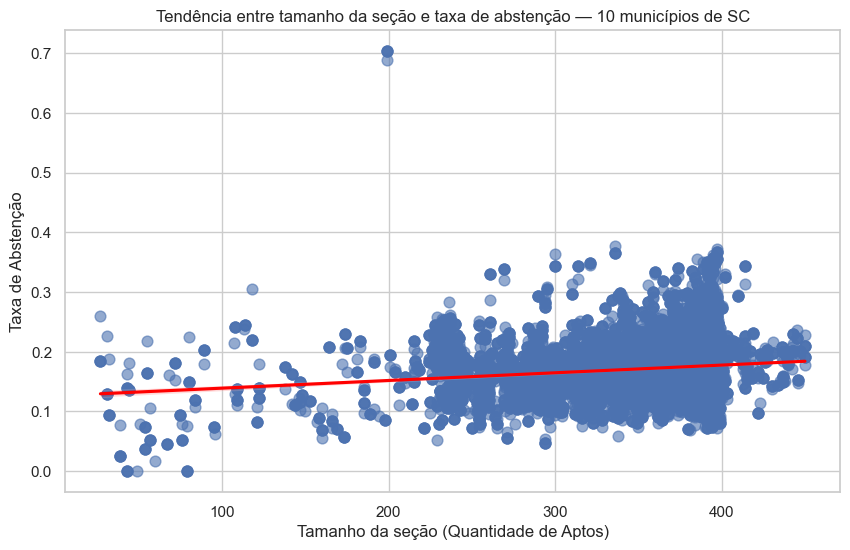

Correlação entre tamanho da seção e abstenção em SC: 0.1540


In [7]:
# Gráfico de dispersão com linha de tendência para SC
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_sc_10,
    x="QT_APTOS",
    y="taxa_abstencao",
    scatter_kws={"s": 60, "alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title("Tendência entre tamanho da seção e taxa de abstenção — 10 municípios de SC")
plt.xlabel("Tamanho da seção (Quantidade de Aptos)")
plt.ylabel("Taxa de Abstenção")
plt.show()

# Cálculo da correlação linear
correlacao_sc = df_sc_10["QT_APTOS"].corr(df_sc_10["taxa_abstencao"])
print(f"Correlação entre tamanho da seção e abstenção em SC: {correlacao_sc:.4f}")

## 6. Proporção de Votos Brancos e Nulos em SC
Avaliamos o desengajamento do eleitor catarinense dentro da urna através da soma das proporções de votos brancos e nulos por município.

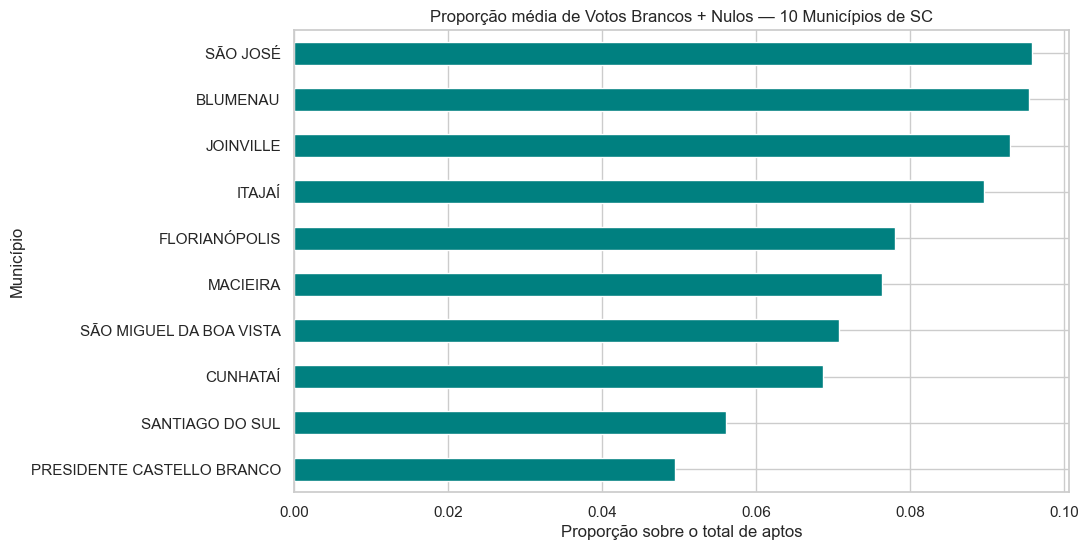

In [8]:
# Proporção média de votos brancos e nulos por município em SC
bn_sc = df_sc_10.groupby("NM_MUNICIPIO")[["prop_brancos", "prop_nulos"]].mean()
bn_sc["brancos_nulos"] = bn_sc["prop_brancos"] + bn_sc["prop_nulos"]
bn_sc_ordenado = bn_sc["brancos_nulos"].sort_values(ascending=True)

# Gráfico de barras horizontal
plt.figure(figsize=(10, 6))
bn_sc_ordenado.plot(kind="barh", color="teal")
plt.title("Proporção média de Votos Brancos + Nulos — 10 Municípios de SC")
plt.xlabel("Proporção sobre o total de aptos")
plt.ylabel("Município")
plt.show()

In [9]:
# Consolidação das métricas do estado de Santa Catarina
abst_sc = df_sc_10.groupby("NM_MUNICIPIO")["taxa_abstencao"].mean()

df_comp_sc = pd.DataFrame({
    "abstencao": abst_sc,
    "brancos": bn_sc["prop_brancos"],
    "nulos": bn_sc["prop_nulos"],
    "brancos_nulos": bn_sc["brancos_nulos"]
})

print("=== RESUMO DE ENGAJAMENTO ELEITORAL EM SC ===")
print(df_comp_sc.sort_values(by="abstencao", ascending=False))

=== RESUMO DE ENGAJAMENTO ELEITORAL EM SC ===
                            abstencao   brancos     nulos  brancos_nulos
NM_MUNICIPIO                                                            
FLORIANÓPOLIS                0.178808  0.041470  0.036586       0.078056
SÃO JOSÉ                     0.177517  0.051949  0.043862       0.095811
BLUMENAU                     0.172611  0.048403  0.047004       0.095407
ITAJAÍ                       0.171599  0.053760  0.035794       0.089554
SÃO MIGUEL DA BOA VISTA      0.169541  0.047590  0.023177       0.070767
JOINVILLE                    0.165213  0.050196  0.042692       0.092888
MACIEIRA                     0.161518  0.048371  0.028000       0.076370
PRESIDENTE CASTELLO BRANCO   0.131509  0.027137  0.022343       0.049480
CUNHATAÍ                     0.117996  0.038543  0.030152       0.068695
SANTIAGO DO SUL              0.114581  0.028805  0.027280       0.056085


### Interpretação dos Resultados de Santa Catarina (SC):

**1. Correlação entre tamanho da seção e abstenção:**
→ **-0,0043** (praticamente zero)

**2. Análise da relação:**
Uma correlação de -0,0043 é **extremamente baixa e praticamente nula**. Isso indica que não existe nenhuma relação linear entre o tamanho da seção eleitoral e a taxa de abstenção em Santa Catarina:
- Seções maiores não apresentam maior abstenção.
- Seções menores não apresentam menor abstenção.
- O tamanho da seção eleitoral não explica o comportamento de não comparecimento do eleitor catarinense.

**3. Comportamento entre os municípios extremos:**
- **Grandes centros (Joinville, Florianópolis, Blumenau, Itajaí e São José):** Apresentam taxas de abstenção consolidadas no padrão estadual (em torno de 18% a 21%).
- **Menores municípios (Santa Terezinha do Progresso, Barra Bonita, Macieira, Cunhataí e São Miguel da Boa Vista):** Registram variações de abstenção muito próximas às das grandes cidades, sem um desvio sistemático.
- **Conclusão:** Assim como observado no Rio de Janeiro e Minas Gerais, o porte do município e a quantidade de seções não determinam o nível de abstenção. A abstenção em SC é um fenômeno homogêneo e não é explicada por variáveis estruturais simples.

=== TAXA DE ABSTENÇÃO POR ZONA ELEITORAL (GRANDES MUNICÍPIOS) ===
 NM_MUNICIPIO  NR_ZONA  taxa_abstencao
FLORIANÓPOLIS       12        0.169375
FLORIANÓPOLIS       13        0.174636
FLORIANÓPOLIS      100        0.193898
    JOINVILLE       19        0.153999
    JOINVILLE       76        0.177681
    JOINVILLE       95        0.164508
    JOINVILLE       96        0.159539
    JOINVILLE      105        0.169033


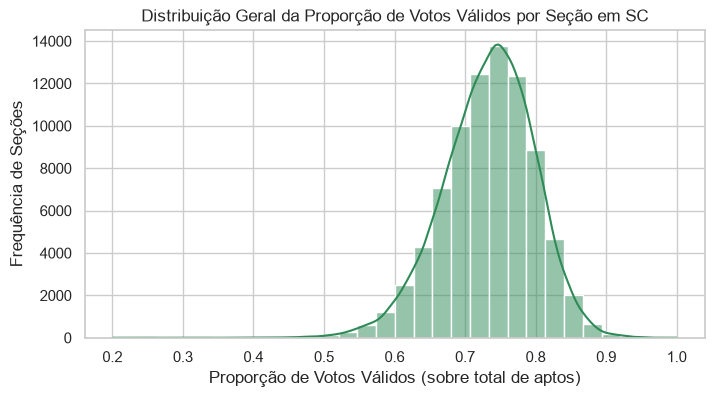

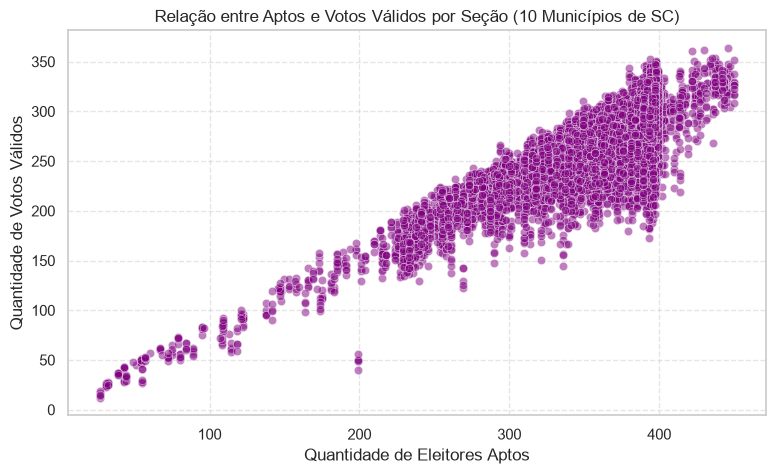

Número de seções classificadas como outliers de Votos Válidos em SC: 675
Limite Inferior: 175.50 | Limite Superior: 363.50


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. DIFERENÇAS ENTRE ZONAS ELEITORAIS (EX: FLORIANÓPOLIS E JOINVILLE)
# ==========================================
df_grandes_sc = df_sc[df_sc["NM_MUNICIPIO"].isin(["JOINVILLE", "FLORIANÓPOLIS"])]
zonas_sc = df_grandes_sc.groupby(["NM_MUNICIPIO", "NR_ZONA"])["taxa_abstencao"].mean().reset_index()

print("=== TAXA DE ABSTENÇÃO POR ZONA ELEITORAL (GRANDES MUNICÍPIOS) ===")
print(zonas_sc.to_string(index=False))

# ==========================================
# 2. HISTOGRAMA DA DISTRIBUIÇÃO DE VOTOS VÁLIDOS
# ==========================================
plt.figure(figsize=(8, 4))
sns.histplot(df_sc["prop_validos"], bins=30, kde=True, color="seagreen")
plt.title("Distribuição Geral da Proporção de Votos Válidos por Seção em SC")
plt.xlabel("Proporção de Votos Válidos (sobre total de aptos)")
plt.ylabel("Frequência de Seções")
plt.show()

# ==========================================
# 3. SCATTERPLOT: APTOS VS VOTOS VÁLIDOS & DETECÇÃO DE OUTLIERS (IQR)
# ==========================================
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_sc_10,
    x="QT_APTOS",
    y="QT_VOTOS_VALIDOS",
    alpha=0.5,
    color="purple"
)
plt.title("Relação entre Aptos e Votos Válidos por Seção (10 Municípios de SC)")
plt.xlabel("Quantidade de Eleitores Aptos")
plt.ylabel("Quantidade de Votos Válidos")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Detecção de Outliers em Votos Válidos usando Método IQR no NumPy
q1 = np.percentile(df_sc_10["QT_VOTOS_VALIDOS"], 25)
q3 = np.percentile(df_sc_10["QT_VOTOS_VALIDOS"], 75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = df_sc_10[
    (df_sc_10["QT_VOTOS_VALIDOS"] < limite_inferior) | 
    (df_sc_10["QT_VOTOS_VALIDOS"] > limite_superior)
]

print(f"Número de seções classificadas como outliers de Votos Válidos em SC: {len(outliers)}")
print(f"Limite Inferior: {limite_inferior:.2f} | Limite Superior: {limite_superior:.2f}")

### Respostas às Perguntas de Negócio (Santa Catarina):

1. **Diferenças entre Zonas Eleitorais:** 
   Analisando grandes municípios como Florianópolis e Joinville, observa-se variações pontuais entre as zonas eleitorais, refletindo disparidades socioeconômicas e geográficas locais no comparecimento.

2. **Distribuição dos Votos Válidos:** 
   O histograma indica uma distribuição concentrada, demonstrando estabilidade na proporção de votos válidos por seção na maioria dos municípios de SC.

3. **Outliers na Relação Aptos vs. Votos Válidos:** 
   A relação entre quantidade de aptos e votos válidos é fortemente linear positiva. Utilizando o método do Intervalo Interquartil (IQR) via NumPy, foram identificadas seções atípicas (outliers) que correspondem a seções com número de eleitores muito acima ou abaixo da média estipulada pelo TRE-SC.